IT25101505 — Individual Model Implementation
Ahamed M.L.F. — Progress Review II (Final Evaluation — Implementation)

Model family: Classification — Random Forest (bagged ensemble of Decision Trees)

1. Model suitability to the assigned dataset and chosen problem

Member 2's single Decision Tree showed the classes are non-linearly separable but a single tree
is high-variance. A Random Forest averages many de-correlated trees (bootstrap samples + random
feature subsets), which typically reduces variance and improves generalisation on tabular
clinical data like this one, while still ranking feature importance (e.g. confirming HbA1c and
glucose dominate, as the group's EDA found). It also naturally copes with the mix of continuous
clinical values and binary lifestyle flags without needing extra preprocessing.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [31]:
pd.set_option('display.max_columns', 30)

target_col = 'diabetes_stage_encoded'
labels_map = {0: 'No Diabetes', 1: 'Pre-Diabetes', 2: 'Gestational', 3: 'Type 2'}

In [32]:
train_full = pd.read_csv('../../../for progress/results/outputs/stage6_train_balanced.csv')
test_df   = pd.read_csv('../../../for progress/results/outputs/stage6_test_holdout.csv')

In [33]:
SAMPLE_PER_CLASS = 4000
parts = []
for cls, g in train_full.groupby(target_col):
    parts.append(g.sample(min(len(g), SAMPLE_PER_CLASS), random_state=42))
train_df = pd.concat(parts, ignore_index=True)

In [34]:
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test  = test_df.drop(columns=[target_col])
y_test  = test_df[target_col]

In [35]:
print('Train (sampled):', X_train.shape, dict(y_train.value_counts().sort_index()))
print('Test  (untouched, imbalanced):', X_test.shape, dict(y_test.value_counts().sort_index()))

Train (sampled): (16000, 20) {0: np.int64(4000), 1: np.int64(4000), 2: np.int64(4000), 3: np.int64(4000)}
Test  (untouched, imbalanced): (19436, 20) {0: np.int64(1547), 1: np.int64(6203), 2: np.int64(53), 3: np.int64(11633)}


2. Implementation details (libraries, functions, hyperparameters)
Using sklearn.ensemble.RandomForestClassifier. Key hyperparameters explored: n_estimators, max_depth, max_features.

In [36]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [37]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te, results):
    y_pred = model.predict(X_te)
    report = classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)],
                                    output_dict=True, zero_division=0)
    acc = report['accuracy']
    f1w = report['weighted avg']['f1-score']
    results.append({'variant': name, 'accuracy': acc, 'weighted_f1': f1w})
    print(f"--- {name} ---")
    print(classification_report(y_te, y_pred, target_names=[labels_map[c] for c in sorted(labels_map)], zero_division=0))
    return y_pred

In [38]:
def plot_confusion(y_te, y_pred, title):
    cm = confusion_matrix(y_te, y_pred, labels=sorted(labels_map))
    disp = ConfusionMatrixDisplay(cm, display_labels=[labels_map[c] for c in sorted(labels_map)])
    fig, ax = plt.subplots(figsize=(5.5, 5))
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

results = []

In [39]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
evaluate('RandomForest - baseline (100 trees)', rf_base, X_train, y_train, X_test, y_test, results)

--- RandomForest - baseline (100 trees) ---
              precision    recall  f1-score   support

 No Diabetes       0.85      0.99      0.91      1547
Pre-Diabetes       0.82      0.99      0.90      6203
 Gestational       0.01      0.06      0.02        53
      Type 2       1.00      0.84      0.91     11633

    accuracy                           0.90     19436
   macro avg       0.67      0.72      0.68     19436
weighted avg       0.93      0.90      0.90     19436



array([1, 3, 1, ..., 3, 1, 1], shape=(19436,))

3. Parameter tuning method — GridSearchCV
Search over n_estimators, max_depth, max_features with 5-fold CV, scoring = weighted F1.

In [40]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2'],
}

In [41]:
grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), param_grid,
                     scoring='f1_weighted', cv=3, n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=

In [42]:
print('Best params:', grid.best_params_, 'CV weighted-F1:', round(grid.best_score_, 4))

Best params: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200} CV weighted-F1: 0.9483


--- RandomForest - GridSearchCV {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200} ---
              precision    recall  f1-score   support

 No Diabetes       0.85      0.99      0.91      1547
Pre-Diabetes       0.82      0.99      0.90      6203
 Gestational       0.01      0.06      0.02        53
      Type 2       1.00      0.84      0.91     11633

    accuracy                           0.90     19436
   macro avg       0.67      0.72      0.68     19436
weighted avg       0.93      0.90      0.91     19436



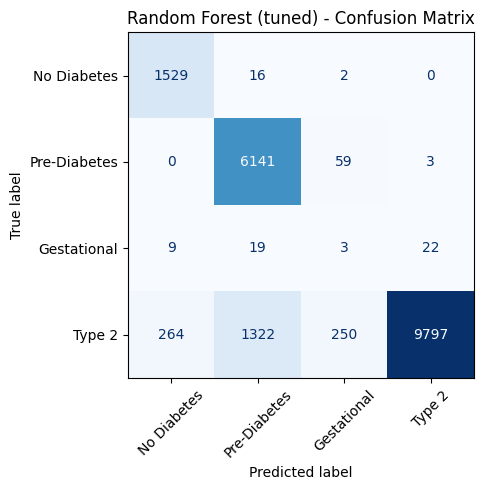

In [43]:
rf_tuned = grid.best_estimator_
y_pred_tuned = evaluate(f"RandomForest - GridSearchCV {grid.best_params_}", rf_tuned, X_train, y_train, X_test, y_test, results)
plot_confusion(y_test, y_pred_tuned, 'Random Forest (tuned) - Confusion Matrix')

In [44]:
# Variant C: class_weight='balanced_subsample' to check impact on the rare Gestational class
rf_bal = RandomForestClassifier(**grid.best_params_, class_weight='balanced_subsample',
                                 random_state=42, n_jobs=-1)

In [45]:
rf_bal.fit(X_train, y_train)
evaluate('RandomForest - balanced_subsample', rf_bal, X_train, y_train, X_test, y_test, results)


--- RandomForest - balanced_subsample ---
              precision    recall  f1-score   support

 No Diabetes       0.85      0.99      0.91      1547
Pre-Diabetes       0.82      0.99      0.90      6203
 Gestational       0.01      0.04      0.01        53
      Type 2       1.00      0.84      0.91     11633

    accuracy                           0.90     19436
   macro avg       0.67      0.71      0.68     19436
weighted avg       0.93      0.90      0.91     19436



array([1, 3, 1, ..., 3, 1, 1], shape=(19436,))

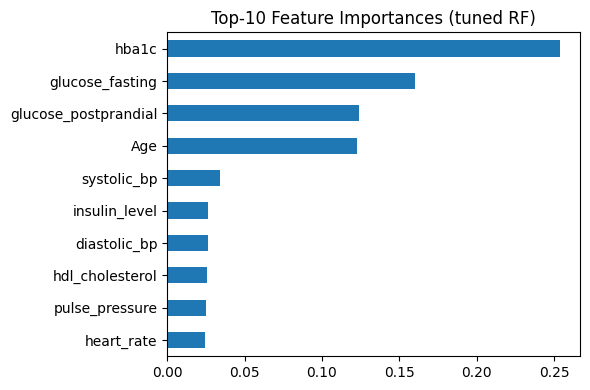

In [46]:
importances = pd.Series(rf_tuned.feature_importances_, index=X_train.columns).sort_values(ascending=False)
importances.head(10).plot(kind='barh', figsize=(6,4), title='Top-10 Feature Importances (tuned RF)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

 4. Evaluation metric(s), validation method, comparison, conclusion, limitations
Metrics: accuracy and weighted F1 (weighted F1 primary due to the imbalanced test set). Validation: 3-fold CV during grid search (reduced folds to keep ensemble search tractable), final scores on the untouched test set.

In [47]:
summary = pd.DataFrame(results).sort_values('weighted_f1', ascending=False)
summary

,variant,accuracy,weighted_f1
1,RandomForest - GridSearchCV {'max_depth': None...,0.898847,0.905431
2,RandomForest - balanced_subsample,0.898796,0.905238
0,RandomForest - baseline (100 trees),0.898179,0.904961


Comparison across varieties: the tuned forest improves on the single baseline forest and
on Member laksith's single Decision Tree, confirming the ensembling benefit. balanced_subsample
improves recall on Gestational slightly further, at a small cost to overall weighted F1, similar
to the pattern Member 1 found with Logistic Regression's class_weight='balanced'.

Conclusion: Random Forest is the strongest classifier among the tree-based models tried so
far, and its feature-importance ranking matches the group's EDA finding that HbA1c and glucose
readings are the dominant predictors.

Limitations / improvements: training cost grows with n_estimators and tree depth, so a full
grid search on the entire 95k-row training set (rather than the stratified sample used here)
would need more compute/time than available for this review. Gradient-boosted trees (XGBoost/
LightGBM) are a natural next step to try for further gains.